## Uncertainty quantification of tranmission coefficients with KDUQ 

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Latex, Math, display
from periodictable import elements

## Compare models to KD

In [2]:
A, Z = (24, 12)

In [3]:
name_core = str(elements[Z].symbol)
display(Math(f"^{{{A}}} \\rm{{{name_core}}}"))

<IPython.core.display.Math object>

## Transmission coefficients
Let's use `jitr` to calculate UQ'ed transmission coefficients using KDUQ Fermi energies and those from a variety of mass models

In [4]:
from tqdm import tqdm

import jitr

In [5]:
neutron = (1, 0)
proton = (1,1)
projectile = proton
target = (A, Z)

In [6]:
# we have 416 samples from the KDUQ posterior
num_samples_kduq = 415
param_files = [
    Path(jitr.data_dir / f"KDUQFederal/{i}/parameters.json").absolute()
    for i in range(0, num_samples_kduq)
]

# load each one
kduq_omp_samples = [
    jitr.optical_potentials.kduq.Global(projectile, Path(param_file))
    for param_file in param_files
]

In [7]:
# com_energy_grid = np.logspace(-1, 1.3, 100)
com_energy_grid = np.array([65, 200])
core_solver = jitr.rmatrix.Solver(50)
range_fm = jitr.utils.interaction_range(A)
lmax = 20
print(range_fm)

3.4613989687377797


In [8]:
reaction = jitr.reactions.Reaction(target=target, projectile=projectile, process="EL")

In [9]:
def set_up_grid(core, com_energy_grid):
    solvers = []
    mn = jitr.utils.constants.MASS_N
    mcore = jitr.utils.mass.mass(*core)[0]
    for i, Ecm in enumerate(tqdm(com_energy_grid)):
        kinematics = jitr.utils.kinematics.classical_kinematics_cm(mcore, mn, Ecm)

        a = range_fm * kinematics.k + np.pi / 2
        N = jitr.utils.suggested_basis_size(a)
        assert N < core_solver.kernel.quadrature.nbasis

        solvers.append(
            jitr.xs.elastic.IntegralWorkspace(
                reaction=reaction,
                kinematics=kinematics,
                channel_radius_fm=a / kinematics.k,
                solver=core_solver,
                lmax=lmax,
                smatrix_abs_tol=0,
            )
        )
    return solvers

In [10]:
solvers = set_up_grid(target, com_energy_grid)

100%|█████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.88s/it]


## Run UQ

In [11]:
N = 400  # number of samples to draw from each posterior
draws_kduq = np.random.choice(len(kduq_omp_samples), size=N)

### KDUQ

In [12]:
tcoeff_kduq = np.zeros((com_energy_grid.size, N, 2, lmax))
for j, sample in enumerate(tqdm(draws_kduq)):
    omp = kduq_omp_samples[sample]

    for i, Ecm in enumerate(com_energy_grid):
        coulomb_params, scalar_params, spin_orbit_params = omp.get_params(
            *target,
            solvers[i].kinematics.Elab,
        )

        tplus, tminus = solvers[i].transmission_coefficients(
            jitr.optical_potentials.kduq.central_plus_coulomb,
            jitr.optical_potentials.kduq.spin_orbit,
            (scalar_params, coulomb_params),
            spin_orbit_params,
        )
        tcoeff_kduq[i, j, 0, :] = tplus
        tcoeff_kduq[i, j, 1, :] = tminus

 24%|██████████████▉                                               | 96/400 [00:11<00:05, 51.22it/s]/home/kyle/umich/jitr/src/jitr/optical_potentials/kduq.py:397: RuntimeWarning: overflow encountered in exp
  d2 = d2_0 + d2_A / (1 + np.exp((A - d2_A3) / d2_A2))
100%|█████████████████████████████████████████████████████████████| 400/400 [00:16<00:00, 23.79it/s]


In [13]:
data = [np.zeros(20)] * 8
names = [
    "E=65 MeV, j = l + 1/2",
    "E=65 MeV, j = l - 1/2",
    "E=65 MeV, j = l + 1/2, err",
    "E=65 MeV, j = l - 1/2, err",
    "E=200 MeV, j = l + 1/2",
    "E=200 MeV, j = l - 1/2",
    "E=200 MeV, j = l + 1/2, err",
    "E=200 MeV, j = l - 1/2, err",
]

In [14]:
from pandas import DataFrame as df

In [15]:
data = df.from_dict(dict(zip(names, data)))

In [16]:
plus_color = "tab:blue"
minus_color = "tab:orange"

In [17]:
from matplotlib import pyplot as plt
from matplotlib import rcParams

plt.rc("font", **{"family": "serif", "serif": ["Computer Modern"]})
plt.rc("text", usetex=True)
rcParams["text.latex.preamble"] = (
    r"\usepackage{amssymb} \usepackage{amsmath} \usepackage{braket}"
)

In [18]:
ci_plus = np.percentile(tcoeff_kduq[0, :, 0, :], 50, axis=0)
ci_plus_errs = np.percentile(tcoeff_kduq[0, :, 0, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[0, :, 0, :], 16, axis=0
)

In [19]:
ci_minus = np.percentile(tcoeff_kduq[0, :, 1, :], 50, axis=0)
ci_minus_errs = np.percentile(tcoeff_kduq[0, :, 1, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[0, :, 1, :], 16, axis=0
)

In [20]:
ci_minus[0] = None
ci_minus_errs[0] = None

In [21]:
data["E=65 MeV, j = l + 1/2"] = ci_plus
data["E=65 MeV, j = l + 1/2, err"] = ci_plus_errs
data["E=65 MeV, j = l - 1/2"] = ci_minus
data["E=65 MeV, j = l - 1/2, err"] = ci_minus_errs

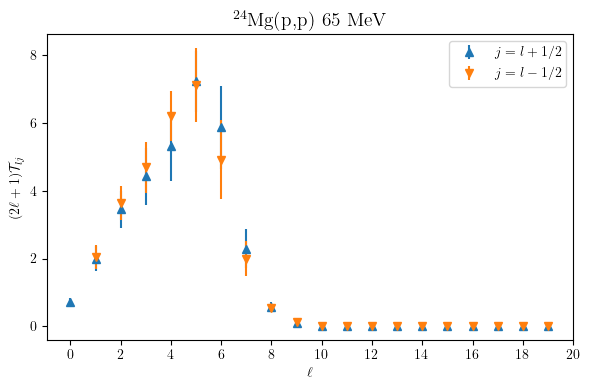

In [22]:
fig = plt.figure(figsize=(6, 4))
ls = np.arange(lmax)
plt.errorbar(
    ls,
    ci_plus * (2 * ls + 1),
    ci_plus_errs * (2 * ls + 1),
    linestyle="none",
    marker="^",
    label="$j = l + 1/2$",
)

plt.errorbar(
    ls[1:],
    ci_minus[1:] * (2 * ls[1:] + 1),
    ci_minus_errs[1:] * (2 * ls[1:] + 1),
    linestyle="none",
    marker="v",
    label="$j = l - 1/2$",
)

# plt.yscale("log")
plt.xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plt.xlabel(r"$\ell$")
plt.ylabel(r"$(2  \ell +1) \mathcal{T}_{lj}$")
plt.title(r"$^{24}$Mg(p,p) 65 MeV", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig("mg24_pp_65mev.pdf")
plt.show()

In [23]:
ci_plus = np.percentile(tcoeff_kduq[1, :, 0, :], 50, axis=0)
ci_plus_errs = np.percentile(tcoeff_kduq[1, :, 0, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[1, :, 0, :], 16, axis=0
)

In [24]:
ci_minus = np.percentile(tcoeff_kduq[1, :, 1, :], 50, axis=0)
ci_minus_errs = np.percentile(tcoeff_kduq[1, :, 1, :], 84, axis=0) - np.percentile(
    tcoeff_kduq[1, :, 1, :], 16, axis=0
)
ci_minus[0] = None
ci_minus_errs[0] = None

In [25]:
data["E=200 MeV, j = l + 1/2"] = ci_plus
data["E=200 MeV, j = l + 1/2, err"] = ci_plus_errs
data["E=200 MeV, j = l - 1/2"] = ci_minus
data["E=200 MeV, j = l - 1/2, err"] = ci_minus_errs

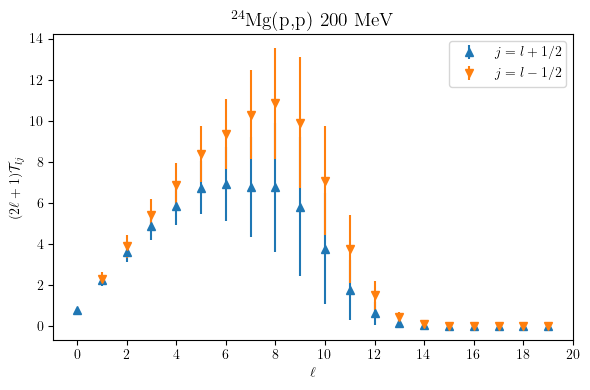

In [26]:
fig = plt.figure(figsize=(6, 4))
ls = np.arange(lmax)
plt.errorbar(
    ls,
    ci_plus * (2 * ls + 1),
    ci_plus_errs * (2 * ls + 1),
    linestyle="none",
    marker="^",
    label="$j = l + 1/2$",
)

plt.errorbar(
    ls[1:],
    ci_minus[1:] * (2 * ls[1:] + 1),
    ci_minus_errs[1:] * (2 * ls[1:] + 1),
    linestyle="none",
    marker="v",
    label="$j = l - 1/2$",
)

# plt.yscale("log")
plt.xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20])
plt.xlabel(r"$\ell$")
plt.ylabel(r"$(2  \ell +1) \mathcal{T}_{lj}$")
plt.title(r"$^{24}$Mg(p,p) 200 MeV", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig("mg24_pp_200mev.pdf")

plt.show()

In [27]:
data.to_csv("./mg24_pp_angular_rxn_xs.csv")